<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/Day_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np

In [ ]:
#cv2.Sobel
#cv2.Laplacian
#cv2.Canny

In [ ]:
!wget 'https://upload.wikimedia.org/wikipedia/commons/thumb/e/e0/Sudoku_Puzzle_by_L2G-20050714_standardized_layout.svg/250px-Sudoku_Puzzle_by_L2G-20050714_standardized_layout.svg.png' -O sudoku.png

--2021-07-05 12:46:52--  https://upload.wikimedia.org/wikipedia/commons/thumb/e/e0/Sudoku_Puzzle_by_L2G-20050714_standardized_layout.svg/250px-Sudoku_Puzzle_by_L2G-20050714_standardized_layout.svg.png
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.153.240, 2620:0:860:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.153.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8009 (7.8K) [image/png]
Saving to: ‘sudoku.png’

sudoku.png          100%[===================>]   7.82K  --.-KB/s    in 0s      

2021-07-05 12:46:53 (57.9 MB/s) - ‘sudoku.png’ saved [8009/8009]



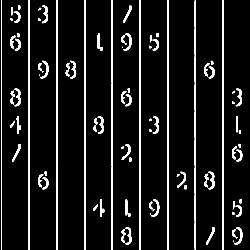

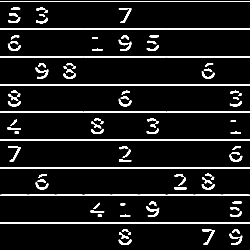

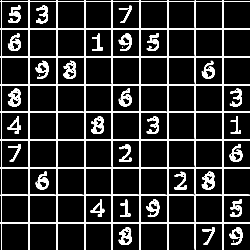

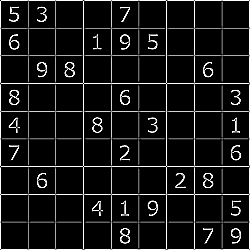

In [ ]:
import cv2
img = cv2.imread('sudoku.png',0)
sobel_x = cv2.Sobel(img,cv2.CV_8U,dx=1,dy=0,ksize=-3)  #ddepth-CV_8U gives values from 0-255 for the pixel in the image
sobel_y = cv2.Sobel(img,cv2.CV_8U,dx=0,dy=1,ksize=-3)
sobel_f = cv2.bitwise_or(sobel_x,sobel_y) #convolution (sobel_x * sobel_y)
cv2_imshow(sobel_x)
cv2_imshow(sobel_y)
cv2_imshow(sobel_f)
laplacian = cv2.Laplacian(img,cv2.CV_8U) #one specific kernel and gives better accuracy in detecting
cv2_imshow(laplacian)



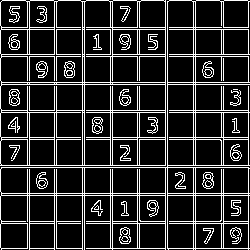

In [ ]:
canny = cv2.Canny(img,20,255)      #threshold 1 and threshold 2 can have values from (0-255)
cv2_imshow(canny)

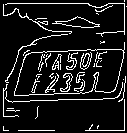

In [ ]:
import cv2
img1 = cv2.imread('/content/plate_1621198909.7971125.png',0)
canny = cv2.Canny(img1,250,200) #trial and error for deciding the threshold (0-255)
cv2_imshow(canny)

In [ ]:
!wget 'https://image.shutterstock.com/image-vector/ontario-canada-car-license-plate-260nw-1869956131.jpg' -O img2.jpg

--2021-07-05 13:23:06--  https://image.shutterstock.com/image-vector/ontario-canada-car-license-plate-260nw-1869956131.jpg
Resolving image.shutterstock.com (image.shutterstock.com)... 13.225.53.97, 13.225.53.96, 13.225.53.10, ...
Connecting to image.shutterstock.com (image.shutterstock.com)|13.225.53.97|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27362 (27K) [image/jpeg]
Saving to: ‘img2.jpg’

img2.jpg            100%[===================>]  26.72K  --.-KB/s    in 0.003s  

2021-07-05 13:23:07 (8.85 MB/s) - ‘img2.jpg’ saved [27362/27362]



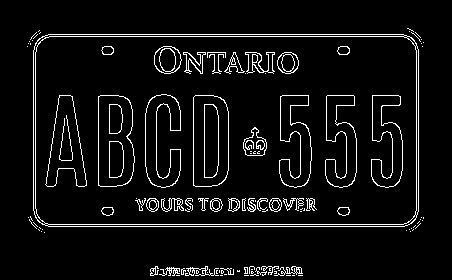

In [ ]:
import cv2
img2 = cv2.imread('img2.jpg',0)
canny = cv2.Canny(img2,200,200) #trial and error for deciding the threshold (0-255)
cv2_imshow(canny)

In [ ]:
import cv2
#import haarcascade classifier #frontal face
model_face = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")#face
model_eye = cv2.CascadeClassifier("haarcascade_eye.xml") #eyes

img = cv2.imread("abc.jpg") #read the image
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #grayscale


face = model_face.detectMultiScale(gray,scaleFactor = 1.1, minNeighbors=9)
eye = model_eye.detectMultiScale(gray,scaleFactor = 1.1, minNeighbors=17)

for x,y,w,h in face:
    cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),5)
    cv2.imshow('Output',img)
    cv2.waitKey(500) #waits for 1000 millisec / 1 sec automatically

for x,y,w,h in eye:
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),3)
    cv2.imshow('Output',img)
    cv2.waitKey(500)   #waits for 1000 millisec automatically

cv2.waitKey(0) #waits for a keypress
cv2.destroyAllWindows()


In [ ]:
#SMILE
import cv2
#import haarcascade classifier #frontal face
smile_cascade = cv2.CascadeClassifier("haarcascade_smile.xml")
cap =cv2.VideoCapture(0)
gray = cv2.cvtColor(cap, cv2.COLOR_BGR2GRAY) #grayscale
smile = smile_cascade.detectMultiScale(gray,scaleFactor = 1.1, minNeighbors=49)
#scalefactor-for magnifying the image a little bit
#minNeighbors used to find the faces of people in the image
for x,y,w,h in smile:   #to detect multiple faces/ search continously
    cv2.rectangle(cap,(x,y),(x+w,y+h),(255,0,0),5)
cv2.imshow("Smile detection",cap) #same as cv_imshow
#cv2_imshow(img)
cv2.waitKey(0) #the window will be there till a key is pressed
cv2.destroyAllWindows()  #deletes the window


In [ ]:
#Video
import cv2

cap = cv2.VideoCapture(0)  #capture a video from my laptop webcam (0) default

while True:   #runs an endless loop to capture multiple frames
    _,frame = cap.read()  #capturing the video
    cv2.imshow('My Sketch',frame)
    if cv2.waitKey(1) == 13: #condition where if 13(ASCII value for Enter key) is pressed only then stop the video
        break
cap.release()  #releasing the port of the webcam used
#if you don't give this line, your webcam can get spoilt (software/hardware)
cv2.destroyAllWindows()


In [ ]:
#Canny video
#Video
import cv2

cap = cv2.VideoCapture(0)  #capture a video from my laptop webcam (0) default

while True:   #runs an endless loop to capture multiple frames
    _,frame = cap.read()  #capturing the video
    canny = cv2.Canny(50,250)
    cv2.imshow('My Canny Sketch',canny)
    if cv2.waitKey(1) == 13: #condition where if 13(ASCII value for Enter key) is pressed only then stop the video
        break
cap.release()  #releasing the port of the webcam used
#if you don't give this line, your webcam can get spoilt (software/hardware)
cv2.destroyAllWindows()
